In [2]:
!pip install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension for CNN: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

# Build simple CNN
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Train model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy (no augmentation): {test_accuracy:.4f}")

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB ?  0:00:57/s eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 10.1 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 9.7 MB/s  0:00:00m352.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 10.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 10.8 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━ 15/16 [tensorflow]  WARNING: The scripts saved_model_cli, tf_upgrade_v2, tflite_convert and toco are installed in '/home/d8cc4292-e27e-4552-add6-e900bb876820/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━

I0000 00:00:1774723856.756784     185 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774723857.489094     185 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774723861.333611     185 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


E0000 00:00:1774723867.128158     185 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8182 - loss: 0.5094 - val_accuracy: 0.8648 - val_loss: 0.3781
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8786 - loss: 0.3363 - val_accuracy: 0.8863 - val_loss: 0.3150
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8957 - loss: 0.2865 - val_accuracy: 0.8950 - val_loss: 0.2943
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9070 - loss: 0.2569 - val_accuracy: 0.8980 - val_loss: 0.2828
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9159 - loss: 0.2302 - val_accuracy: 0.9053 - val_loss: 0.2586
Test Accuracy (no augmentation): 0.8989


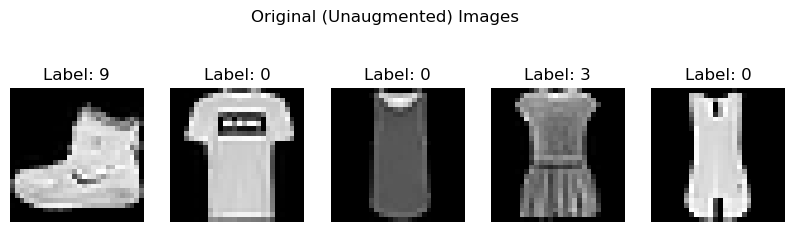

In [6]:
# Show original images
plt.figure(figsize=(10, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Original (Unaugmented) Images")
plt.show()

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create augmented data generator
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)

# Build a fresh model for fair comparison
aug_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

aug_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train using augmented images
aug_history = aug_model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=5,
    validation_data=(x_test, y_test),
    verbose=1
)

# Evaluate augmented model
aug_test_loss, aug_test_accuracy = aug_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy (with augmentation): {aug_test_accuracy:.4f}")

Epoch 1/5


I0000 00:00:1774724012.828125     185 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.7479 - loss: 0.6708 - val_accuracy: 0.8248 - val_loss: 0.4954
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.8143 - loss: 0.4853 - val_accuracy: 0.8532 - val_loss: 0.3873
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.8379 - loss: 0.4294 - val_accuracy: 0.8750 - val_loss: 0.3401
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.8508 - loss: 0.3969 - val_accuracy: 0.8288 - val_loss: 0.4108
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.8594 - loss: 0.3713 - val_accuracy: 0.8831 - val_loss: 0.3171
Test Accuracy (with augmentation): 0.8831


In [4]:
print(f"Without augmentation: {test_accuracy:.4f}")
print(f"With augmentation:    {aug_test_accuracy:.4f}")
print(f"Difference:           {aug_test_accuracy - test_accuracy:.4f}")

Without augmentation: 0.8989
With augmentation:    0.8831
Difference:           -0.0158


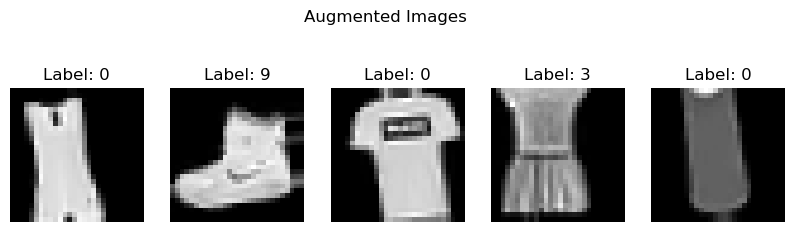

In [7]:
# Show augmented versions of the SAME images
augmented_images = next(datagen.flow(x_train[:5], y_train[:5], batch_size=5))

plt.figure(figsize=(10, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_images[0][i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {augmented_images[1][i]}")
    plt.axis("off")

plt.suptitle("Augmented Images")
plt.show()

##What I learned

I learned that data augmentation can help a neural networks can be trained on slightly altered data and get very similar results. The augmented data likely helps it learn different patterns and possibly identify new data that it hasn't seen before. The model learns patterns that still matter when an image is shifted, rotated, or zoomed. In my experiment, augmentation accuracy was very similar to the real test data. 

##Challenges

One challenge that I ran into when running the code on the Anaconda website is that I started to get limited on my computering power.  As we learn more advanced techniques, I wonder if this will become a bigger issue. 

##Real-world applications

These techniques are useful in real-world applications where collecting large amounts of labeled data is difficult or expensive. For example, in my job, as we develop new AP course and subsequent AP exams, we don't have scored exams from previous years.  Using a LLM, generative AI, and other methods might help us create a scoring model while never seeing real student exams.  